#### K-Means(평균을 이용한 군집화)
- k개의 그룹으로 자동 분류하는 비지도 학습 알고리즘
- 종속 변수가 존재하지 않는 데이터에서 유사한 데이터끼리 모음
- 서로 가까운 데이터는 같은 그룹으로 묶어서 그룹화
- 그룹의 중심점을 반복적으로 계산(중심점의 이동)하여 군집을 형성

- 작업 순서
    - 초기의 중심점(k개)을 선택
    - 각각의 데이터들을 줌심점과의 거리를 확인
    - 가까운 거리를 중심점을 할당
    - 각 군집의 평균을 구해서 새로운 중심점 설정
    - 중심점의 변화가 거의 없을때까지 반복 실행
- 장점
    - 빠르고 단순하여 대용량의 데이터에서 적합
- 단점
    - 군집의 수를 미리 알고 작성해야한다는 점
    - 이상치에 굉장히 민감
- parameter
    - n_clusters
        - 기본값 : 8
        - 군집의 개수를 지정
        - 너무 작거나 큰 경우는 성능 저하 기능
    - init
        - 기본값 : 'k_means++
        - 초기의 중심점을 설정하는 방법
        - 기본값을 사용하면 빠르고 안정적
        - 'random' : 무작위하게 중심점을 설정
    - n_init
        - 기본값 : 'auto' (구버전 10)
        - 초기화 횟수
        - 초기화하여 여러번의 시도를 통해 최적의 결과를 만드는 방법
    - max_iter
        - 기본값 : 300
        - 한번의 실행에서 최대의 반복 횟수
    - tol
        - 기본값 : 1e-4
        - 중심점의 이동의 변화량이 이 값보다 작은 경우에는 수렴
    - algorithm
        - 기본값 : 'lloyd'
        - 'elkan' : 속도 향상 ( 밀집 데이터에서 유리 )
- 속성
    - coluster_center
        - 각 군집의 중심점 좌표
    - labels_
        - 각 데이터의 군집의 번호
    - inertia_
        - 군집 내의 거리 제곱합
        - 작을수록 군집이 응집되어있음
    - n_iter_
        - 마지막 반복에서의 수행 횟수(중심점 이동 횟수)
- 메서드
    - fit(X)
        - 모델의 학습
    - predict()
        - 세로운 데이터를 이용하여 군집화 예측
    - transform()
        - 각 데이터와 각 중심점간의 거리를 행렬로 변환하여 출력
    - score()
        - _inertia값을 반환
    - get_parmas() / set_parmas()
- 검증 방법
    - inertia_
        - 군집 내의 거리 제곱의 합(작을수록 응집)
    - silhouette_score (실루엣 점수)
        - 응집도 + 분리도의 종합 점수(1에 가까울수록 좋음)
    - calinski_Harabasz_score
        - 군집 간의 분산 / 군집 내의 분산 비율 (높을수록 좋음)
    - davies_Bouldin score
        - 군집 간의 유사도 평균 (낮을수록 좋음)
    - adjusted_rand_score
        - 실제의 라벨과 군집의 일치도(1 = 일치, 0 = 불일치)

In [13]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score


In [2]:
iris = pd.read_csv('../csv/iris.csv')

In [3]:
iris.head(1)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa


In [4]:
x = iris.drop('species',axis=1)
y = iris['species']

In [7]:
# 군집화는 일반적으로 Scaler를 사용
x_std = StandardScaler().fit_transform(x)

In [8]:
# Kmeans 객체 생성
model = KMeans(
    n_clusters=3, random_state=42, n_init = 10
)

In [9]:
model.fit(x_std)
labels = model.predict(x_std)

In [10]:
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0])

In [11]:
x_std

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [12]:
# 검증 지표(군집이 얼마나 잘되었는가)
inertia = model.inertia_
silhouette = silhouette_score(x_std, labels)
calinski = calinski_harabasz_score(x_std, labels)
davies = davies_bouldin_score(x_std,  labels)
# 실제 라벨과의 계산
ari = adjusted_rand_score(y, labels)

print('inertia : ', round(inertia, 3))
print('silhouette : ',round(silhouette,3))
print('calinski : ', round(calinski,3))
print('davies : ', round(davies,3))
print('ARI : ', round(ari, 3))

inertia :  139.82
silhouette :  0.46
calinski :  241.904
davies :  0.834
ARI :  0.62


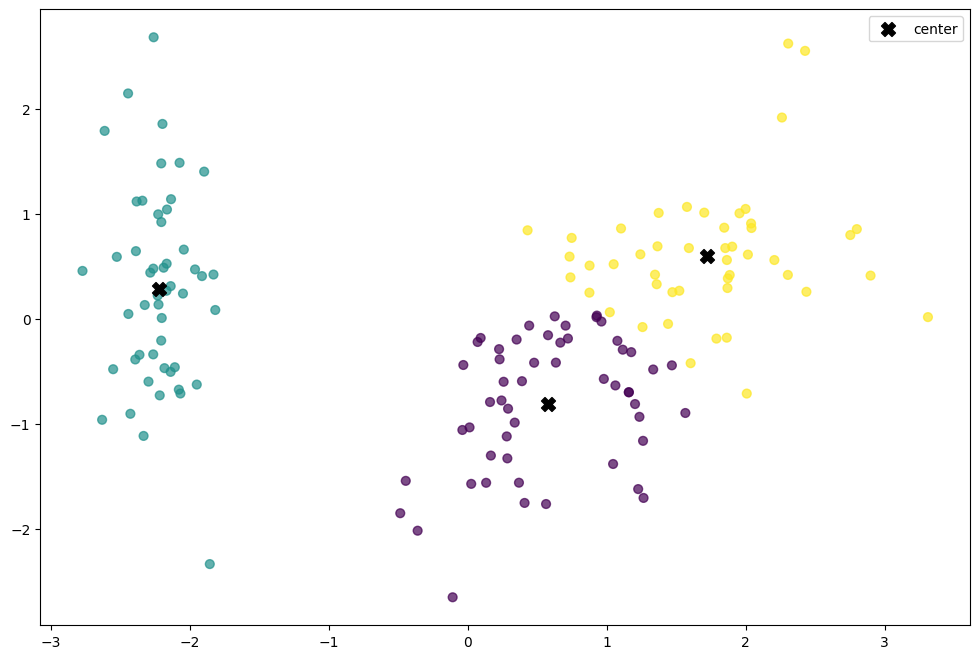

In [14]:
# 군집의 상황을 2차원 그래프로 시각화 -> 차원 축소
pca = PCA(n_components=2)
# 4차원 데이터를 2차원으로 차원 축소
x_pca = pca.fit_transform(x_std)
# 중심점을 pca를 이용해서 2차원으로 축소
center_pca = pca.transform(model.cluster_centers_)

plt.figure(figsize=(12, 8))
plt.scatter(
        x_pca[:,0], x_pca[:,1], c = labels, cmap='viridis', s = 40, alpha = 0.7
)
plt.scatter(
        center_pca[:,0], center_pca[:,1], c='black',s=100, marker = 'X', label = 'center'
)
plt.legend()
plt.show()


In [15]:
# bodyperformance 데이터를 이용한 군집
df = pd.read_csv('../data/bodyperformance.csv')

In [17]:
df.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,M,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C
1,25.0,M,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A
2,31.0,M,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C


In [18]:
from sklearn.preprocessing import LabelEncoder

In [20]:
# labelencoding 하려는 컬럼들이 다수 존재한다면 -> object형 컬럼의 이름들을 모두 추출
obj_cols = df.select_dtypes('object').columns

In [22]:
for col in obj_cols:
    # print(col)
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [23]:
df.head(3)

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2


In [24]:
# 범주형 데이터들을 제외한 독립 변수를 생성
x = df.drop(['gender','class'], axis = 1)
y1 = df['class']
y2 = df['gender']


In [25]:
x_std = StandardScaler().fit_transform(x)

In [27]:
# 검증 지표 (실루엣 점수) 확인
# 군집의 개수는 2~10개 까지 확인
# 검증 지표들을 하나의 리스트에 저장
rows = []

for k in range(2, 11):
    # k -> 군집의 개수
    km = KMeans(n_clusters=k, n_init = 10, random_state=42)
    pred = km.fit_predict(x_std)
    # 검증지표
    iner = km.inertia_
    sil = silhouette_score(x_std, pred)
    
    row = {
        'K' : k,
        'inertia' : iner,
        'silhouette' : sil
    }

    rows.append(row)

In [29]:
scores = pd.DataFrame(rows)
scores.sort_values('silhouette',ascending=False)

,K,inertia,silhouette
0,2,92209.116383,0.285521
1,3,80763.188170,0.212558
2,4,71405.576102,0.200472
4,6,62240.243243,0.176855
3,5,66252.724674,0.172895
5,7,59232.077009,0.159284
6,8,57055.449406,0.150871
7,9,55019.760843,0.143290
8,10,53510.303369,0.134315


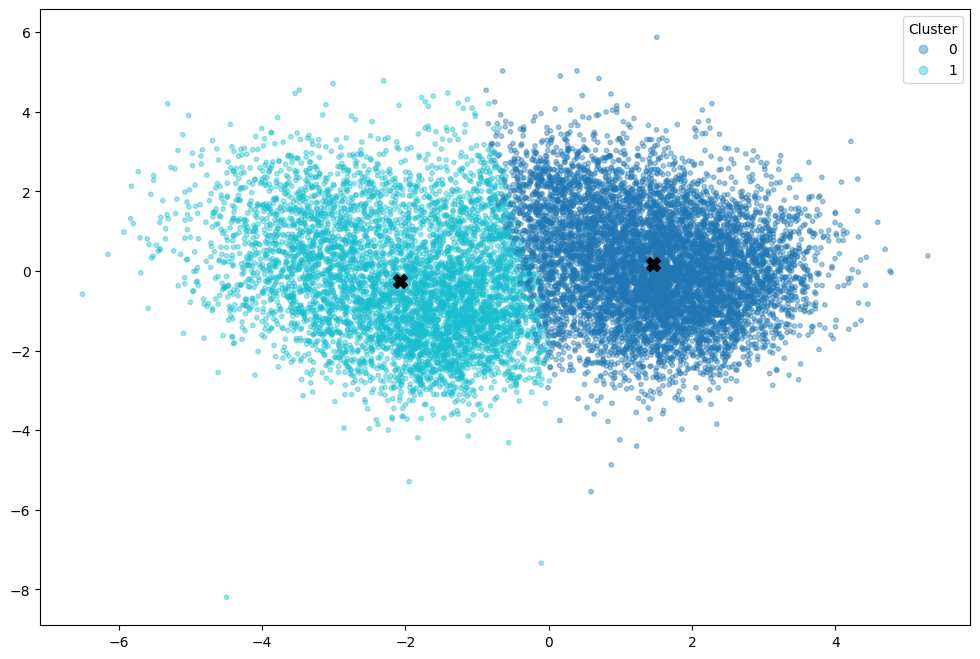

In [34]:
# 군집의 개수가 2인 경우 중심점과 차원축소로 2차원의 데이터의 분포도
pca = PCA(n_components=2, random_state=42)
# 2차원으로 차원 축소
x_pca = pca.fit_transform(x_std)

km_best = KMeans(n_clusters=2, n_init=10, random_state=42).fit(x_std)

labels_best = km_best.labels_
center_best = km_best.cluster_centers_
# 중심점을 2차원으로 축소
center_pca = pca.transform(center_best)

plt.figure(figsize = (12,8))

sc = plt.scatter(x_pca[:, 0], x_pca[:,1],c=labels_best,s=10,cmap='tab10',alpha=0.4)

plt.scatter(center_pca[:,0], center_pca[:,1], c = 'black', s= 100, marker = 'X', label = 'center')

plt.legend(*sc.legend_elements(), title = 'Cluster')
plt.show()

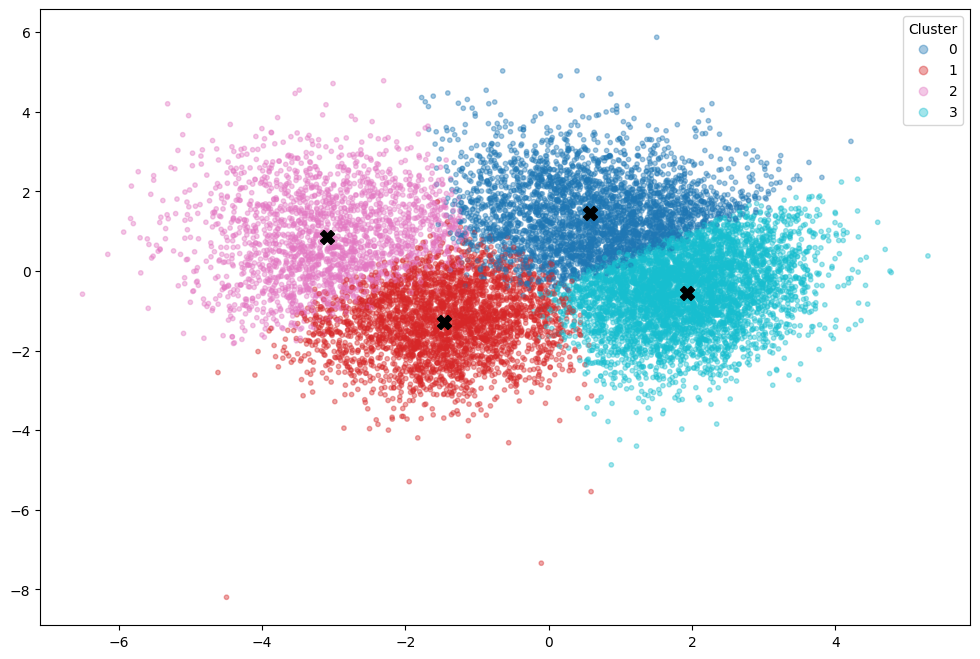

In [35]:
# 군집의 개수가 2인 경우 중심점과 차원축소로 2차원의 데이터의 분포도
pca = PCA(n_components=2, random_state=42)
# 2차원으로 차원 축소
x_pca = pca.fit_transform(x_std)

km_best = KMeans(n_clusters=4, n_init=10, random_state=42).fit(x_std)

labels_best = km_best.labels_
center_best = km_best.cluster_centers_
# 중심점을 2차원으로 축소
center_pca = pca.transform(center_best)

plt.figure(figsize = (12,8))

sc = plt.scatter(x_pca[:, 0], x_pca[:,1],c=labels_best,s=10,cmap='tab10',alpha=0.4)

plt.scatter(center_pca[:,0], center_pca[:,1], c = 'black', s= 100, marker = 'X', label = 'center')

plt.legend(*sc.legend_elements(), title = 'Cluster')
plt.show()

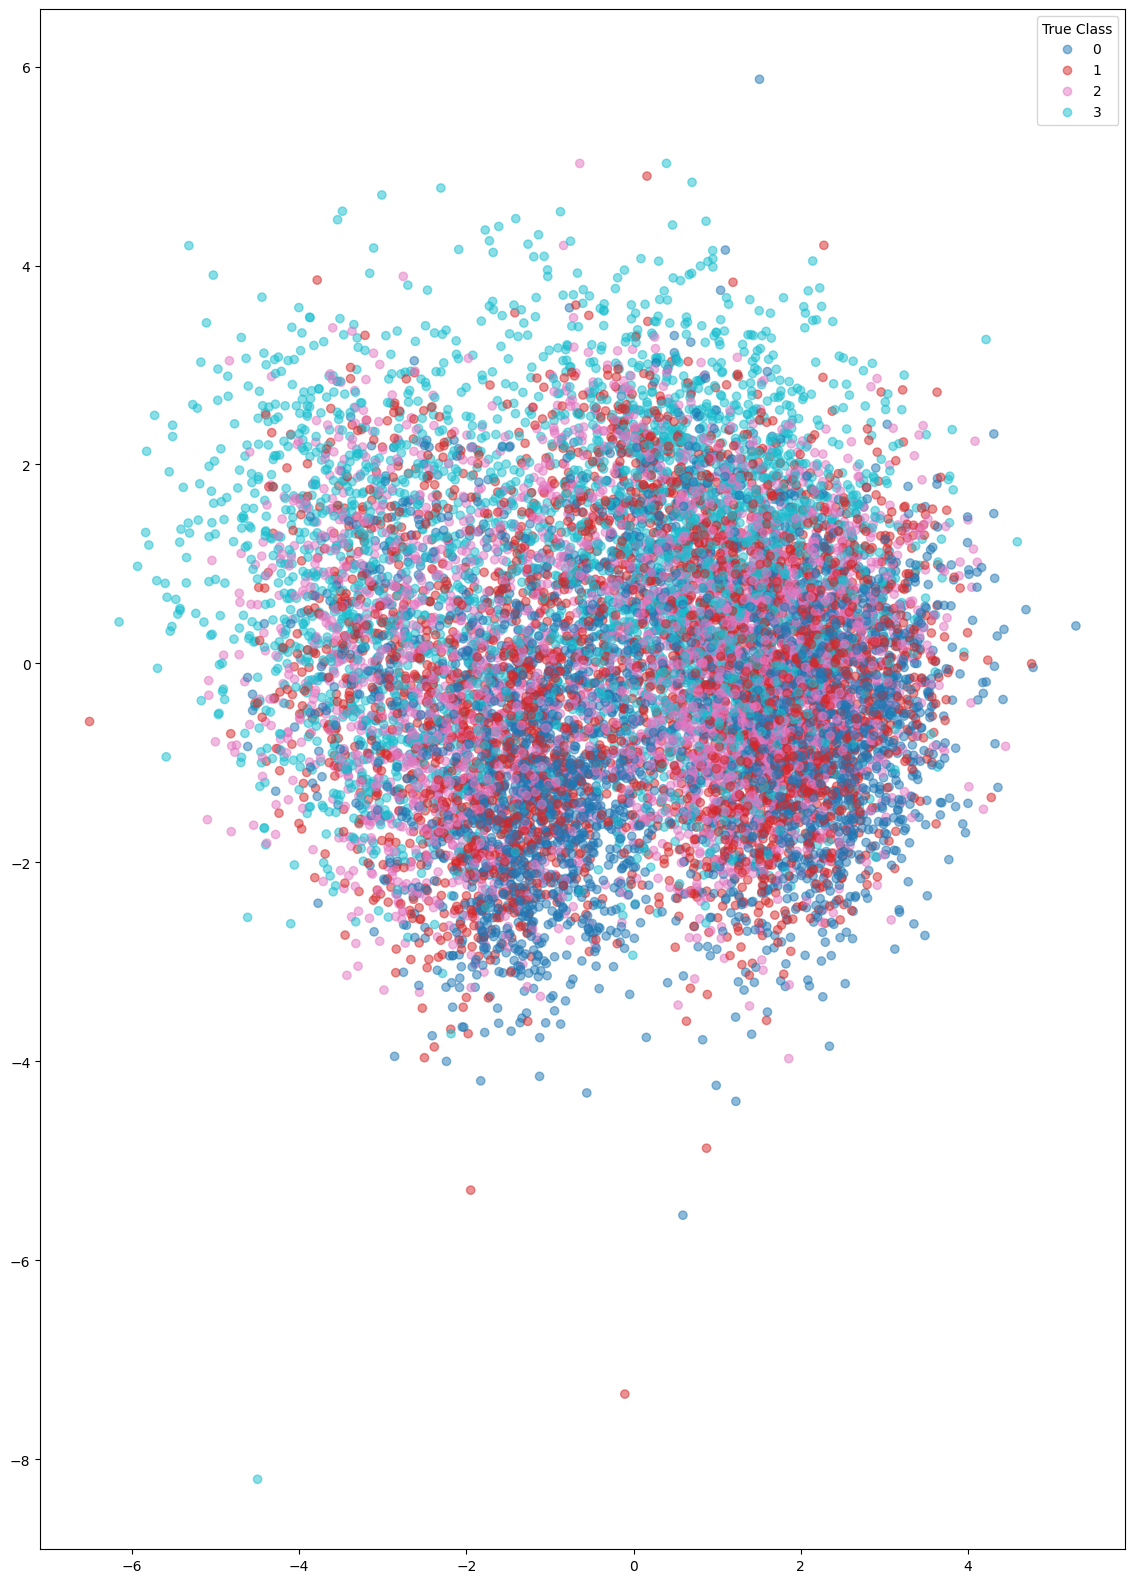

In [37]:
# class컬럼 별 데이터의 분포를 확인
plt.figure(figsize=(14, 20))

sc_class = plt.scatter(
    x_pca[:,0], x_pca[:,1], c= y1, cmap = 'tab10', alpha = 0.5
)

plt.legend(*sc_class.legend_elements(),title = 'True Class')

plt.show()

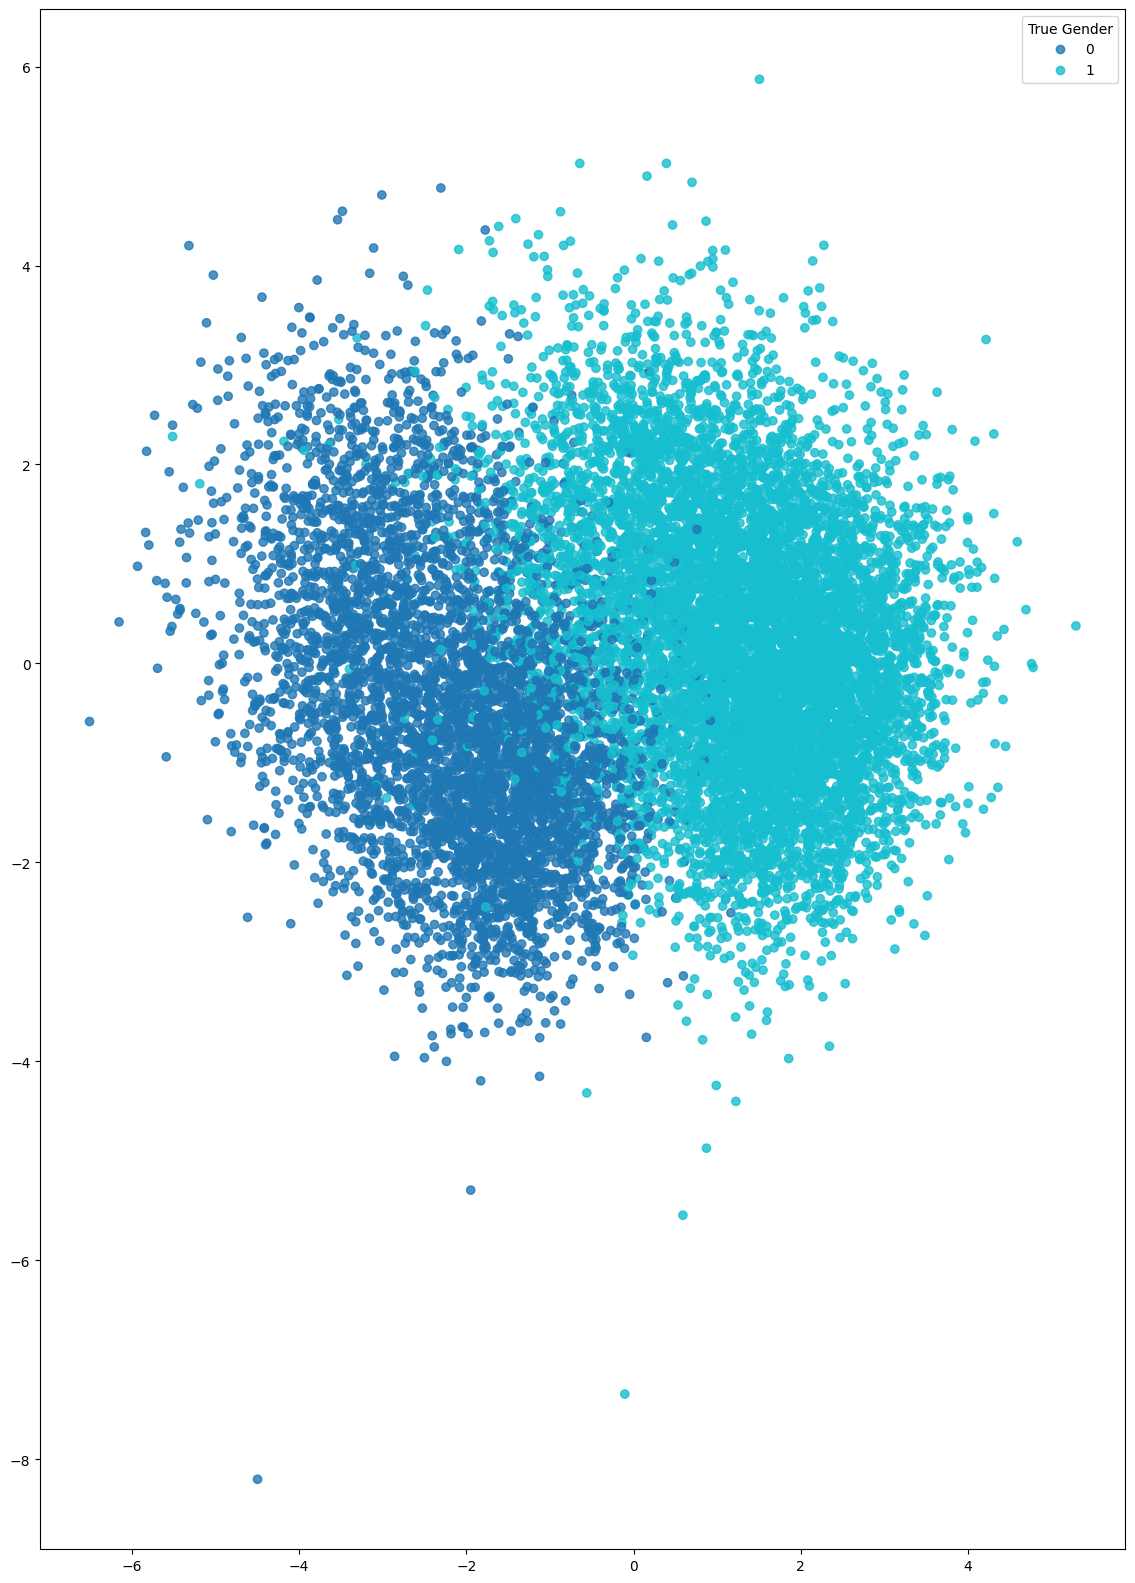

In [38]:
# class컬럼 별 데이터의 분포를 확인
plt.figure(figsize=(14, 20))

sc_class = plt.scatter(
    x_pca[:,0], x_pca[:,1], c= y2, cmap = 'tab10', alpha = 0.8
)

plt.legend(*sc_class.legend_elements(),title = 'True Gender')

plt.show()